In [2]:
import pandas as pd

In [7]:
logreg_tox_fm = pd.read_csv("output/logreg/metrics_cv_logreg_toxicity_male_female.csv")
rf_tox_fm = pd.read_csv("output/random_forest/metrics_cv_rf_toxicity_male_female.csv")
svm_tox_fm = pd.read_csv("output/svm/metrics_cv_svm_toxicity_male_female.csv")

In [8]:
logreg_tox_fm.head(5)

,sex,fold,threshold,auroc,balanced_accuracy,sensitivity,precision,f1
0,M,0,0.671508,0.807882,0.788177,0.862069,0.862069,0.862069
1,M,1,0.671946,0.773399,0.753695,0.793103,0.851852,0.821429
2,M,2,0.595820,0.748768,0.665025,0.758621,0.785714,0.771930
3,M,3,0.882769,0.797619,0.759524,0.785714,0.846154,0.814815
4,M,4,0.966798,0.818878,0.750000,0.571429,0.941176,0.711111


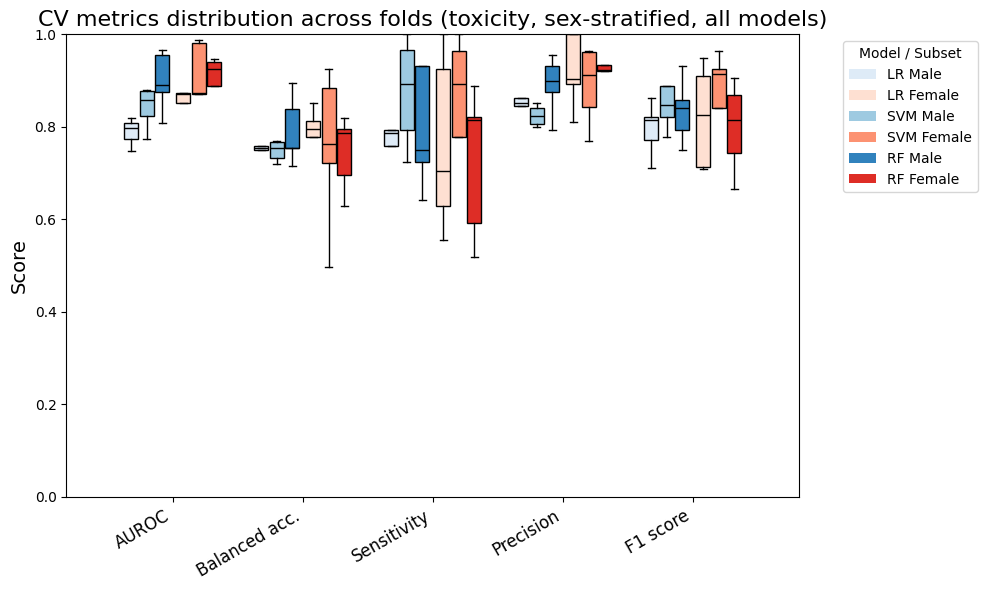

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Ensure the required DataFrames are loaded:
# logreg_tox_fm, svm_tox_fm, rf_tox_fm

# Add model labels
logreg_tox_fm_ = logreg_tox_fm.copy()
logreg_tox_fm_["model"] = "LR"

svm_tox_fm_ = svm_tox_fm.copy()
svm_tox_fm_["model"] = "SVM"

rf_tox_fm_ = rf_tox_fm.copy()
rf_tox_fm_["model"] = "RF"

# Concatenate all results
cv_results = pd.concat([logreg_tox_fm_, svm_tox_fm_, rf_tox_fm_], ignore_index=True)

# Map sex to full labels for the legend
sex_map = {"M": "Male", "F": "Female"}
cv_results["sex_full"] = cv_results["sex"].map(sex_map)

# List of metrics in the desired order
metrics = ["auroc", "balanced_accuracy", "sensitivity", "precision", "f1"]

# Tidy/long format
cv_tidy = cv_results.melt(
    id_vars=["model", "sex_full", "fold"],
    value_vars=metrics,
    var_name="metric",
    value_name="value",
)

# Color mapping as specified
colors = {
    ("LR", "Male"): "#deebf7",
    ("SVM",    "Male"): "#9ecae1",
    ("RF",     "Male"): "#3182bd",
    ("LR", "Female"): "#fee0d2",
    ("SVM",    "Female"): "#fc9272",
    ("RF",     "Female"): "#de2d26",
}

models = ["LR", "SVM", "RF"]
sexes = ["Male", "Female"]

x_metrics = np.arange(len(metrics))
width_sex = 0.36          # total width allocated per sex at each metric
width_model = width_sex / len(models)

fig, ax = plt.subplots(figsize=(10, 6))

for s_idx, sex in enumerate(sexes):
    # Center offset for male vs female
    sex_center_offset = (s_idx - 0.5) * (width_sex + 0.04)

    for m_idx, model in enumerate(models):
        # Offset for each model within a sex
        box_offset = (m_idx - 1) * width_model
        positions = x_metrics + sex_center_offset + box_offset

        data_for_boxes = []
        for metric in metrics:
            vals = cv_tidy.query(
                "model == @model and sex_full == @sex and metric == @metric"
            )["value"]
            data_for_boxes.append(vals.values)

        color = colors[(model, sex)]
        bp = ax.boxplot(
            data_for_boxes,
            positions=positions,
            widths=width_model * 0.9,
            patch_artist=True,
            showfliers=False,
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_edgecolor("black")
        for element in ["whiskers", "caps", "medians"]:
            plt.setp(bp[element], color="black", linewidth=1)

# X axis labels
ax.set_xticks(x_metrics)
ax.set_xticklabels([
    "AUROC",
    "Balanced acc.",
    "Sensitivity",
    "Precision",
    "F1 score",
], rotation=30, ha="right", fontsize=12)

ax.set_ylabel("Score", fontsize=14)
ax.set_title("CV metrics distribution across folds (toxicity, sex-stratified, all models)", fontsize=16)

# Fix y-axis from 0 to 1
ax.set_ylim(0, 1)

# Legend
handles = []
for model in models:
    for sex in sexes:
        handles.append(
            mpatches.Patch(
                facecolor=colors[(model, sex)],
                label=f"{model} {sex}",
            )
        )

ax.legend(handles=handles, title="Model / Subset", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.margins(x=0.05)
plt.tight_layout()

# Ensure output directory exists and save figure in both PDF and PNG
os.makedirs("output", exist_ok=True)
fig_path_pdf = os.path.join(
    "output", "cv_metrics_toxicity_sex_all_models_boxplot.pdf"
)
fig_path_png = os.path.join(
    "output", "cv_metrics_toxicity_sex_all_models_boxplot.png"
)

plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, bbox_inches="tight", dpi=300)

plt.show()